# Step 3.1.2.5: EFPI与Shape Graphs阵型识别对比可视化

## 目标

对比两种基准方法的阵型识别结果：
1. **EFPI (Elastic Formation and Position Identification)**: 基于模板匹配的方法
2. **Shape Graphs**: 基于凸包分解和垂直层级的方法

## 可视化内容

- 顶部显示：半场、时间、球队名称、宏观战术标签
- 底部显示：Shape Graphs阵型 vs EFPI阵型
- 球员节点：双色半圆设计（垂直层级+水平位置）
- Shape Graph边结构

## 数据来源

- Shape Graphs结果: `3.1.2.2_test_ShapeGraphs_Batch_Processing.ipynb`
- EFPI结果: `3.1.1_test_EFPI_Formation_Identification.ipynb`
- 宏观战术标签: `1.3_test_Tactical_Intent.ipynb`

## 1. 导入库和配置

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, FFMpegWriter
import networkx as nx
import pickle
from pathlib import Path
from datetime import timedelta
from tqdm import tqdm
import sys

# 添加Step2路径以导入守门员识别模块
sys.path.insert(0, str(Path('../../../Step2_Graph_Representation/Test').resolve()))
from goalkeeper_identifier import identify_goalkeeper, separate_players_and_ball

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 比赛信息
GAME_ID = 10517  # 2022世界杯决赛 (Argentina vs France)
HOME_TEAM_ID = '364'  # 阿根廷 (Argentina)
AWAY_TEAM_ID = '363'  # 法国 (France)
HOME_TEAM_NAME = 'Argentina'
AWAY_TEAM_NAME = 'France'

# 数据路径
DATA_DIR = Path('../../../data/morph_test')
RESULTS_DIR = DATA_DIR / 'shapegraphs_baseline'
GRAPHS_DIR = DATA_DIR / 'shape_graphs' / 'graphs'
EFPI_DIR = DATA_DIR / 'efpi_baseline'  # EFPI基准结果目录
OUTPUT_DIR = RESULTS_DIR / 'comparison_videos'  # 对比可视化专用目录
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"配置完成")
print(f"比赛: 2022世界杯决赛 (Game {GAME_ID})")
print(f"主队: {HOME_TEAM_NAME} (Team ID: {HOME_TEAM_ID})")
print(f"客队: {AWAY_TEAM_NAME} (Team ID: {AWAY_TEAM_ID})")

配置完成
比赛: 2022世界杯决赛 (Game 10517)
主队: Argentina (Team ID: 364)
客队: France (Team ID: 363)


## 2. 定义色块标注配色方案

根据原论文Fig 3和Fig 4的配色方案：
- **F (Forward)**: 深红色 `#8B0000`
- **AM (Attacking Midfielder)**: 浅红色 `#FFB6C1`
- **M (Midfielder)**: 灰色 `#D3D3D3`
- **DM (Defensive Midfielder)**: 浅蓝色 `#ADD8E6`
- **B (Back/Defender)**: 深蓝色 `#00008B`

In [2]:
# 垂直层级配色方案（上半圆，参考原论文Fig 3）
VERTICAL_COLORS = {
    'F': "#C40000",    # 深红色 - Forward
    'AM': "#F97676",   # 浅红色 - Attacking Midfielder
    'M': '#D3D3D3',    # 灰色 - Midfielder
    'DM': "#6FBDD6",   # 浅蓝色 - Defensive Midfielder
    'B': "#1748CE"     # 深蓝色 - Back/Defender
}

# 水平位置配色方案（下半圆，参考原论文Fig 4底部）
HORIZONTAL_COLORS = {
    'L': "#6D3710",    # 棕色 - Left
    'LC': '#D2B48C',   # 浅棕色 - Left-Center
    'C': "#D3D3D3",    # 米色/浅灰 - Center
    'RC': "#90CD90",   # 浅绿色 - Right-Center
    'R': "#307030"     # 深绿色 - Right
}

# 垂直层级名称（中英文）
VERTICAL_NAMES = {
    'F': 'Forward (前锋)',
    'AM': 'Attacking Mid (攻击型中场)',
    'M': 'Midfielder (中场)',
    'DM': 'Defensive Mid (防守型中场)',
    'B': 'Back (后卫)'
}

# 水平位置名称（中英文）
HORIZONTAL_NAMES = {
    'L': 'Left (左)',
    'LC': 'Left-Center (中左)',
    'C': 'Center (中)',
    'RC': 'Right-Center (中右)',
    'R': 'Right (右)'
}

# 球场参数（SecondSpectrum坐标系统）
PITCH_LENGTH = 105  # 米
PITCH_WIDTH = 68    # 米
X_MIN, X_MAX = -52.5, 52.5
Y_MIN, Y_MAX = -34, 34

print("配色方案定义完成")
print("\n垂直层级（上半圆）:")
for level, color in VERTICAL_COLORS.items():
    print(f"  {level}: {VERTICAL_NAMES[level]} - {color}")
print("\n水平位置（下半圆）:")
for pos, color in HORIZONTAL_COLORS.items():
    print(f"  {pos}: {HORIZONTAL_NAMES[pos]} - {color}")

配色方案定义完成

垂直层级（上半圆）:
  F: Forward (前锋) - #C40000
  AM: Attacking Mid (攻击型中场) - #F97676
  M: Midfielder (中场) - #D3D3D3
  DM: Defensive Mid (防守型中场) - #6FBDD6
  B: Back (后卫) - #1748CE

水平位置（下半圆）:
  L: Left (左) - #6D3710
  LC: Left-Center (中左) - #D2B48C
  C: Center (中) - #D3D3D3
  RC: Right-Center (中右) - #90CD90
  R: Right (右) - #307030


## 3. 加载Shape Graphs结果和追踪数据

In [3]:
# 加载Shape Graphs阵型识别结果
results_file = RESULTS_DIR / f'shapegraphs_baseline_results_{GAME_ID}.parquet'
results_df = pd.read_parquet(results_file)

print(f"加载Shape Graphs结果: {len(results_df)} 帧")
print(f"列: {results_df.columns.tolist()}")
print(f"\n前5行:")
print(results_df.head())

# 加载追踪数据（用于获取时间戳信息和球员球衣号码映射）
tracking_file = DATA_DIR / f'tracking_data_{GAME_ID}.parquet'
tracking_pl = pl.read_parquet(tracking_file)

print(f"\n加载追踪数据: {tracking_pl.shape[0]} 行")

# 🔧 创建球员ID到球衣号码的映射（从kloppy数据集）
from kloppy import pff
METADATA_FILE = Path(r"E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData\Gradient Sports  Enhanced 2022 World Cup Dataset\Metadata\10517.json")
ROSTER_FILE = Path(r"E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData\Gradient Sports  Enhanced 2022 World Cup Dataset\Rosters\10517.json")
TRACKING_FILE = Path(r"E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData\Gradient Sports  Enhanced 2022 World Cup Dataset\Tracking Data\10517.jsonl.bz2")

kloppy_dataset = pff.load_tracking(
    meta_data=str(METADATA_FILE),
    roster_meta_data=str(ROSTER_FILE),
    raw_data=str(TRACKING_FILE),
    coordinates="secondspectrum",
    only_alive=True
)

# 建立球员ID到球衣号码的映射字典
player_id_to_jersey = {}
for team in kloppy_dataset.metadata.teams:
    for player in team.players:
        player_id_to_jersey[player.player_id] = player.jersey_no

print(f"\n球员ID到球衣号码映射: {len(player_id_to_jersey)} 名球员")
print(f"示例映射: {dict(list(player_id_to_jersey.items())[:5])}")

# 加载EFPI结果
efpi_file = EFPI_DIR / f'efpi_baseline_results_{GAME_ID}_fullmatch.parquet'
efpi_df = pl.read_parquet(efpi_file)
print(f"\n加载EFPI结果: {len(efpi_df)} 行")

# 加载追踪数据（包含战术标签）
tracking_file_tactical = DATA_DIR / f'tracking_data_{GAME_ID}_tactical_labels.parquet'
if tracking_file_tactical.exists():
    tracking_pl_tactical = pl.read_parquet(tracking_file_tactical)
    print(f"加载追踪数据（含战术标签）: {tracking_pl_tactical.shape[0]} 行")
    # 检查是否包含新格式（macro_phase和fine_intent）或旧格式（tactical_label）
    if 'macro_phase' in tracking_pl_tactical.columns and 'fine_intent' in tracking_pl_tactical.columns:
        tracking_pl = tracking_pl_tactical
        print("✅ 使用含战术标签的追踪数据（新格式：macro_phase和fine_intent）")
    elif 'tactical_label' in tracking_pl_tactical.columns:
        tracking_pl = tracking_pl_tactical
        print("✅ 使用含战术标签的追踪数据（旧格式：tactical_label）")
    else:
        print("⚠️ 战术标签文件存在但不包含预期的列")
else:
    print("⚠️ 未找到战术标签数据")

# 数据合并：添加EFPI阵型和战术标签到results_df
print("\n合并EFPI和战术标签数据...")

# 提取EFPI阵型
efpi_home = efpi_df.filter((pl.col('team_id') == HOME_TEAM_ID) & (pl.col('id') != 'ball'))
efpi_formations = efpi_home.group_by('frame_id').agg([pl.col('formation').first().alias('efpi_formation')])

# 提取战术标签（两级体系：macro_phase和fine_intent）
if 'macro_phase' in tracking_pl.columns and 'fine_intent' in tracking_pl.columns:
    print("✅ 检测到新格式战术标签（macro_phase和fine_intent）")
    tactical_labels = tracking_pl.filter(
        (pl.col('team_id') == HOME_TEAM_ID) & (pl.col('id').is_not_null())
    ).group_by('frame_id').agg([
        pl.col('macro_phase').first().alias('macro_phase'),
        pl.col('fine_intent').first().alias('fine_intent')
    ])
    print(f"战术标签提取完成: {tactical_labels.shape[0]} 帧")
    print(f"macro_phase唯一值: {tactical_labels['macro_phase'].unique().to_list()}")
    print(f"fine_intent唯一值: {tactical_labels['fine_intent'].unique().to_list()}")
elif 'tactical_label' in tracking_pl.columns:
    # 兼容旧格式：如果只有tactical_label列，则使用临时解析逻辑
    print("⚠️ 检测到旧格式tactical_label，建议重新运行1.3_test_Tactical_Intent.ipynb生成新数据")
    tactical_labels = tracking_pl.filter(
        (pl.col('team_id') == HOME_TEAM_ID) & (pl.col('id').is_not_null())
    ).group_by('frame_id').agg([
        pl.col('tactical_label').first().alias('tactical_label')
    ])
else:
    print("❌ 未找到战术标签列，使用默认值")
    tactical_labels = pl.DataFrame({
        'frame_id': results_df['frame_id'].tolist(), 
        'macro_phase': ['Unknown'] * len(results_df),
        'fine_intent': [None] * len(results_df)
    })

# 合并到results_df
results_pl = pl.from_pandas(results_df)
results_pl = results_pl.join(efpi_formations, on='frame_id', how='left')
results_pl = results_pl.join(tactical_labels, on='frame_id', how='left')
results_df = results_pl.to_pandas()

print(f"✅ 合并完成: {len(results_df)} 帧")
print(f"\n示例数据:")
# 根据可用列显示示例数据
if 'macro_phase' in results_df.columns and 'fine_intent' in results_df.columns:
    print(results_df[['frame_id', 'formation_smoothed', 'efpi_formation', 'macro_phase', 'fine_intent']].head())
    # 检查是否有Unknown值
    unknown_count = (results_df['macro_phase'] == 'Unknown').sum()
    null_count = results_df['macro_phase'].isna().sum()
    print(f"\n⚠️ macro_phase为'Unknown'的帧数: {unknown_count}")
    print(f"⚠️ macro_phase为null的帧数: {null_count}")
elif 'tactical_label' in results_df.columns:
    print(results_df[['frame_id', 'formation_smoothed', 'efpi_formation', 'tactical_label']].head())
else:
    print(results_df[['frame_id', 'formation_smoothed', 'efpi_formation']].head())

加载Shape Graphs结果: 50084 帧
列: ['frame_id', 'formation', 'formation_code', 'formation_detailed', 'n_defenders', 'n_dm', 'n_midfielders', 'n_am', 'n_forwards', 'vertical_levels', 'horizontal_positions', 'formation_smoothed', 'formation_code_smoothed', 'formation_detailed_smoothed']

前5行:
   frame_id formation formation_code formation_detailed  n_defenders  n_dm  \
0     10018     2-5-3        2(014)3              20143            1     1   
1     10019     2-5-3        2(014)3              20143            1     1   
2     10020     2-5-3        2(014)3              20143            1     1   
3     10021     2-5-3        2(014)3              20143            1     1   
4     10022     3-5-2        3(212)2              32122            3     2   

   n_midfielders  n_am  n_forwards                      vertical_levels  \
0              1     4           3  [F, DM, AM, M, F, B, AM, AM, F, AM]   
1              1     4           3  [F, DM, AM, M, F, B, AM, AM, F, AM]   
2              1    

## 4. 定义可视化函数

In [4]:
def draw_pitch(ax):
    """
    绘制足球场（横向，SecondSpectrum坐标系统）
    """
    # 清空坐标轴
    ax.clear()
    
    # 设置画幅范围
    ax.set_xlim(X_MIN - 3, X_MAX + 3)  # 左右各扩展3米
    ax.set_ylim(Y_MIN - 3, Y_MAX + 3)  # 上下各扩展3米
    ax.set_aspect('equal')
    ax.axis('off')
    
    # 绿色草坪
    grass_rect = patches.Rectangle(
        (X_MIN - 5, Y_MIN - 5), PITCH_LENGTH + 10, PITCH_WIDTH + 10,  # 草坪范围
        linewidth=0, facecolor="#3DA742", zorder=0
    )
    ax.add_patch(grass_rect)
    
    # 球场边界（白线）
    pitch_rect = patches.Rectangle(
        (X_MIN, Y_MIN), PITCH_LENGTH, PITCH_WIDTH,
        linewidth=2, edgecolor='white', facecolor='none', zorder=1  # 边界线
    )
    ax.add_patch(pitch_rect)
    
    # 球门（在底线上用加粗线段表示门框范围）
    goal_width = 7.32  # 球门宽度（米）
    goal_y_min = -goal_width / 2
    goal_y_max = goal_width / 2
    
    # 左侧球门（底线上的加粗线段）
    ax.plot([X_MIN, X_MIN], [goal_y_min, goal_y_max], color='white', linewidth=4, zorder=2)
    
    # 右侧球门（底线上的加粗线段）
    ax.plot([X_MAX, X_MAX], [goal_y_min, goal_y_max], color='white', linewidth=4, zorder=2)
    
    # 中线
    ax.plot([0, 0], [Y_MIN, Y_MAX], color='white', linewidth=2, zorder=1)
    
    # 中圈
    center_circle = patches.Circle(
        (0, 0), 9.15, linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(center_circle)
    
    # 中点（开球点，增大尺寸）
    ax.plot(0, 0, 'o', color='white', markersize=8, zorder=1)  # 从markersize=3增加到8
    
    # 禁区（左侧）
    left_penalty = patches.Rectangle(
        (X_MIN, -20.16), 16.5, 40.32,
        linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(left_penalty)
    
    # 禁区（右侧）
    right_penalty = patches.Rectangle(
        (X_MAX - 16.5, -20.16), 16.5, 40.32,
        linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(right_penalty)
    
    # 小禁区（左侧）
    left_goal_area = patches.Rectangle(
        (X_MIN, -9.16), 5.5, 18.32,
        linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(left_goal_area)
    
    # 小禁区（右侧）
    right_goal_area = patches.Rectangle(
        (X_MAX - 5.5, -9.16), 5.5, 18.32,
        linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(right_goal_area)
    
    # 点球点（左侧）
    penalty_spot_x = 11  # 点球点距球门线11米
    ax.plot(X_MIN + penalty_spot_x, 0, 'o', color='white', markersize=6, zorder=1)  # 点球点大小
    
    # 点球点（右侧）
    ax.plot(X_MAX - penalty_spot_x, 0, 'o', color='white', markersize=6, zorder=1)  # 点球点大小
    
    # 点球弧（左侧）
    penalty_arc_radius = 9.15  # 点球弧半径（米）
    penalty_arc_center_x = X_MIN + penalty_spot_x  # 点球弧圆心X坐标
    # 计算点球弧的起始和结束角度（只绘制禁区外的部分）
    import numpy as np
    penalty_box_edge_x = X_MIN + 16.5  # 禁区边缘X坐标
    # 计算弧与禁区边缘的交点角度
    theta_intersect = np.degrees(np.arccos((penalty_box_edge_x - penalty_arc_center_x) / penalty_arc_radius))
    # 左侧点球弧：从禁区边缘开始，逆时针绘制到另一侧禁区边缘（禁区外的弧）
    theta_start = theta_intersect  # 起始角度（上方交点）
    theta_end = 360 - theta_intersect  # 结束角度（下方交点）
    left_penalty_arc = patches.Arc(
        (penalty_arc_center_x, 0), 2 * penalty_arc_radius, 2 * penalty_arc_radius,
        angle=0, theta1=theta_end, theta2=theta_start,  # 修正：theta1和theta2互换，绘制禁区外的弧
        linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(left_penalty_arc)
    
    # 点球弧（右侧）
    penalty_arc_center_x_right = X_MAX - penalty_spot_x  # 右侧点球弧圆心X坐标
    penalty_box_edge_x_right = X_MAX - 16.5  # 右侧禁区边缘X坐标
    # 右侧点球弧：从禁区边缘开始，顺时针绘制到另一侧禁区边缘（禁区外的弧）
    theta_start_right = 180 - theta_intersect  # 起始角度（上方交点）
    theta_end_right = 180 + theta_intersect  # 结束角度（下方交点）
    right_penalty_arc = patches.Arc(
        (penalty_arc_center_x_right, 0), 2 * penalty_arc_radius, 2 * penalty_arc_radius,
        angle=0, theta1=theta_start_right, theta2=theta_end_right,  # 绘制禁区外的弧
        linewidth=2, edgecolor='white', facecolor='none', zorder=1
    )
    ax.add_patch(right_penalty_arc)
    
    return ax


def visualize_comparison_frame(ax, frame_id, results_row, show_info=True):
    """
    可视化单帧的Shape Graph
    
    参数:
        ax: matplotlib axes对象
        frame_id: 帧ID
        results_row: 该帧的结果数据（包含vertical_levels等）
        show_info: 是否显示信息文本
    """
    # 绘制球场
    draw_pitch(ax)
    
    # 加载Shape Graph
    graph_file = GRAPHS_DIR / f'shape_graph_{frame_id}.pkl'
    if not graph_file.exists():
        ax.text(0, 0, f'Frame {frame_id}\nNo data', 
                ha='center', va='center', fontsize=20, color='white')
        return
    
    with open(graph_file, 'rb') as f:
        data = pickle.load(f)
    
    graph = data['graph']
    positions = data['positions']
    field_players = data['field_players']  # 获取球员信息（包含球衣号码）
    
    # 获取垂直层级和水平位置分配
    vertical_levels = results_row['vertical_levels']
    horizontal_positions = results_row['horizontal_positions']
    
    # 🔧 新增：获取并绘制足球位置
    frame_data = tracking_pl.filter(pl.col('frame_id') == frame_id)
    if len(frame_data) > 0:
        # 获取球的位置（从球员数据中筛选出球的记录）
        # 球的team_id通常为None或特殊标识，id为'ball'或类似
        ball_data = frame_data.filter(pl.col('id') == 'ball')
        if len(ball_data) > 0:
            ball_x = ball_data['x'][0]
            ball_y = ball_data['y'][0]
            
            # 绘制足球（白色圆圈，黑色边框）
            ball_circle = patches.Circle(
                (ball_x, ball_y), radius=0.8,  # 足球半径稍小
                facecolor='white', edgecolor='black', linewidth=2.5,
                zorder=5  # 确保球在最上层
            )
            ax.add_patch(ball_circle)
            
            # 添加足球标记（黑色五边形图案）
            ax.plot(ball_x, ball_y, 'ko', markersize=3, zorder=6)

    # 绘制Shape Graph的边
    for edge in graph.edges():
        i, j = edge
        x_coords = [positions[i][0], positions[j][0]]
        y_coords = [positions[i][1], positions[j][1]]
        ax.plot(x_coords, y_coords, 'k-', linewidth=1.5, alpha=0.6, zorder=2)
    
    # 绘制球员节点（双色半圆设计，参考原论文Fig 4）
    node_radius = 1.5  # 节点半径（米）
    
    for i, pos in enumerate(positions):
        # 获取垂直层级和水平位置
        v_level = vertical_levels[i]
        h_pos = horizontal_positions[i]
        
        # 获取对应颜色
        v_color = VERTICAL_COLORS.get(v_level, '#808080')  # 默认灰色
        h_color = HORIZONTAL_COLORS.get(h_pos, '#808080')  # 默认灰色
        
        # 绘制上半圆（垂直层级）
        upper_wedge = patches.Wedge(
            center=pos, r=node_radius, 
            theta1=0, theta2=180,  # 上半圆
            facecolor=v_color, edgecolor='grey', linewidth=2,
            zorder=3
        )
        ax.add_patch(upper_wedge)
        
        # 绘制下半圆（水平位置）
        lower_wedge = patches.Wedge(
            center=pos, r=node_radius,
            theta1=180, theta2=360,  # 下半圆
            facecolor=h_color, edgecolor='grey', linewidth=2,
            zorder=3
        )
        ax.add_patch(lower_wedge)
        
        # 🔧 修复：使用真实的球衣号码而不是索引
        player_id = str(field_players.iloc[i]['id'])  # 获取球员ID
        jersey_number = player_id_to_jersey.get(player_id, i+1)  # 使用映射字典转换为球衣号码
        ax.text(pos[0], pos[1], str(jersey_number), 
                ha='center', va='center', 
                fontsize=11, fontweight='bold', color='black',
                zorder=4)
    
    # 显示信息文本
    if show_info:
        # 🔧 修改：使用已获取的frame_data（避免重复查询）
        if len(frame_data) > 0:
            period_id = frame_data['period_id'][0]
            timestamp = frame_data['timestamp'][0]
            
            # 计算比赛时间（分:秒）
            if isinstance(timestamp, timedelta):
                total_seconds = int(timestamp.total_seconds())
            else:
                total_seconds = int(timestamp)
            
            minutes = total_seconds // 60
            seconds = total_seconds % 60
            time_str = f"{minutes:02d}:{seconds:02d}"
            
            # 半场信息
            half_str = f"Half: {period_id}"
        else:
            time_str = "--:--"
            half_str = "Half: -"
        
        # 获取战术标签（两级体系：macro_phase和fine_intent）
        macro_phase = results_row.get('macro_phase', None)
        fine_intent = results_row.get('fine_intent', None)
        
        # 如果新格式列存在，直接使用
        if macro_phase is not None and not pd.isna(macro_phase):
            if fine_intent is not None and not pd.isna(fine_intent):
                tactical_label_text = f"{macro_phase}: {fine_intent}"
            else:
                tactical_label_text = str(macro_phase)
        # 否则尝试从旧格式tactical_label解析（兼容性）
        elif 'tactical_label' in results_row.index:
            tactical_label = results_row.get('tactical_label', 'unknown')
            if pd.isna(tactical_label) or tactical_label == 'unknown':
                tactical_label_text = 'Unknown'
            else:
                # 临时解析逻辑（兼容旧数据）
                tactical_label_upper = str(tactical_label).upper()
                
                if 'BUILD_UP' in tactical_label_upper:
                    macro_phase = 'In-Possession Open Play'
                    fine_intent = 'Build-up'
                elif 'ATTACKING_PLAY' in tactical_label_upper:
                    macro_phase = 'In-Possession Open Play'
                    fine_intent = 'Attacking-play'
                elif 'HIGH_BLOCK' in tactical_label_upper:
                    macro_phase = 'Out-of-Possession Open Play'
                    fine_intent = 'High-block'
                elif 'MID_BLOCK' in tactical_label_upper:
                    macro_phase = 'Out-of-Possession Open Play'
                    fine_intent = 'Mid-block'
                elif 'LOW_BLOCK' in tactical_label_upper:
                    macro_phase = 'Out-of-Possession Open Play'
                    fine_intent = 'Low-block'
                else:
                    macro_phase = 'Unknown'
                    fine_intent = str(tactical_label)
                
                tactical_label_text = f"{macro_phase}: {fine_intent}"
        else:
            tactical_label_text = 'Unknown'
        
        info_text = f"{half_str}, Time: {time_str}\n{HOME_TEAM_NAME} - {tactical_label_text}"
        # 顶部文本框：位置更贴近球场（Y_MAX + 4），字体更大（fontsize=16），文本框更大（pad=0.8）
        ax.text(0, Y_MAX + 4, info_text,  # 文本框位置：球场顶部上方4米
                ha='center', va='bottom',
                fontsize=16, fontweight='bold', color='black',  # 字体大小：16
                bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.9))  # 文本框padding：0.8
        
        # 显示帧ID（用于调试）
        frame_text = f"Frame {frame_id}"
        ax.text(X_MIN, Y_MAX + 4, frame_text,  # 文本框位置：球场左上角上方4米
                ha='left', va='bottom',
                fontsize=12, color='gray',  # 字体大小：12
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))  # 文本框padding：0.5
        
        # 显示阵型（底部）- 使用详细5位数格式，但去掉0
        # 获取Shape Graphs阵型（优先formation_detailed_smoothed）
        if 'formation_detailed_smoothed' in results_row.index:
            sg_formation_raw = results_row['formation_detailed_smoothed']  # 如'32203'（包含0）
        elif 'formation_detailed' in results_row.index:
            sg_formation_raw = results_row['formation_detailed']
        else:
            # 向后兼容：手动计算（旧数据）
            from collections import Counter
            level_counts = Counter(vertical_levels)
            b = level_counts.get('B',0)
            d = level_counts.get('DM',0)
            m = level_counts.get('M',0)
            a = level_counts.get('AM',0)
            f = level_counts.get('F',0)
            sg_formation_raw = f"{b}{d}{m}{a}{f}"
        
        # 去掉0显示（如'32203' → '3223'）
        sg_formation = sg_formation_raw.replace('0', '')
        
        # EFPI阵型
        efpi_formation = results_row.get('efpi_formation', 'N/A')
        if pd.isna(efpi_formation):
            efpi_formation = 'N/A'
        
        formation_text = f"Shape Graphs Formation: {sg_formation}     EFPI Formation: {efpi_formation}"
        # 底部文本框：位置更贴近球场（Y_MIN - 4），字体更大（fontsize=18），文本框更大（pad=0.8）
        ax.text(0, Y_MIN - 4, formation_text,  # 文本框位置：球场底部下方4米
                ha='center', va='top',
                fontsize=18, fontweight='bold', color='black',  # 字体大小：18
                bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.9))  # 文本框padding：0.8
    
    return ax


print("可视化函数定义完成（更新Shape Graph阵型显示逻辑：去掉0）")

可视化函数定义完成（更新Shape Graph阵型显示逻辑：去掉0）


## 5. 测试单帧可视化

测试帧: 60031
阵型: 3-5-2
垂直层级: ['F' 'B' 'AM' 'DM' 'F' 'M' 'AM' 'B' 'AM' 'AM']


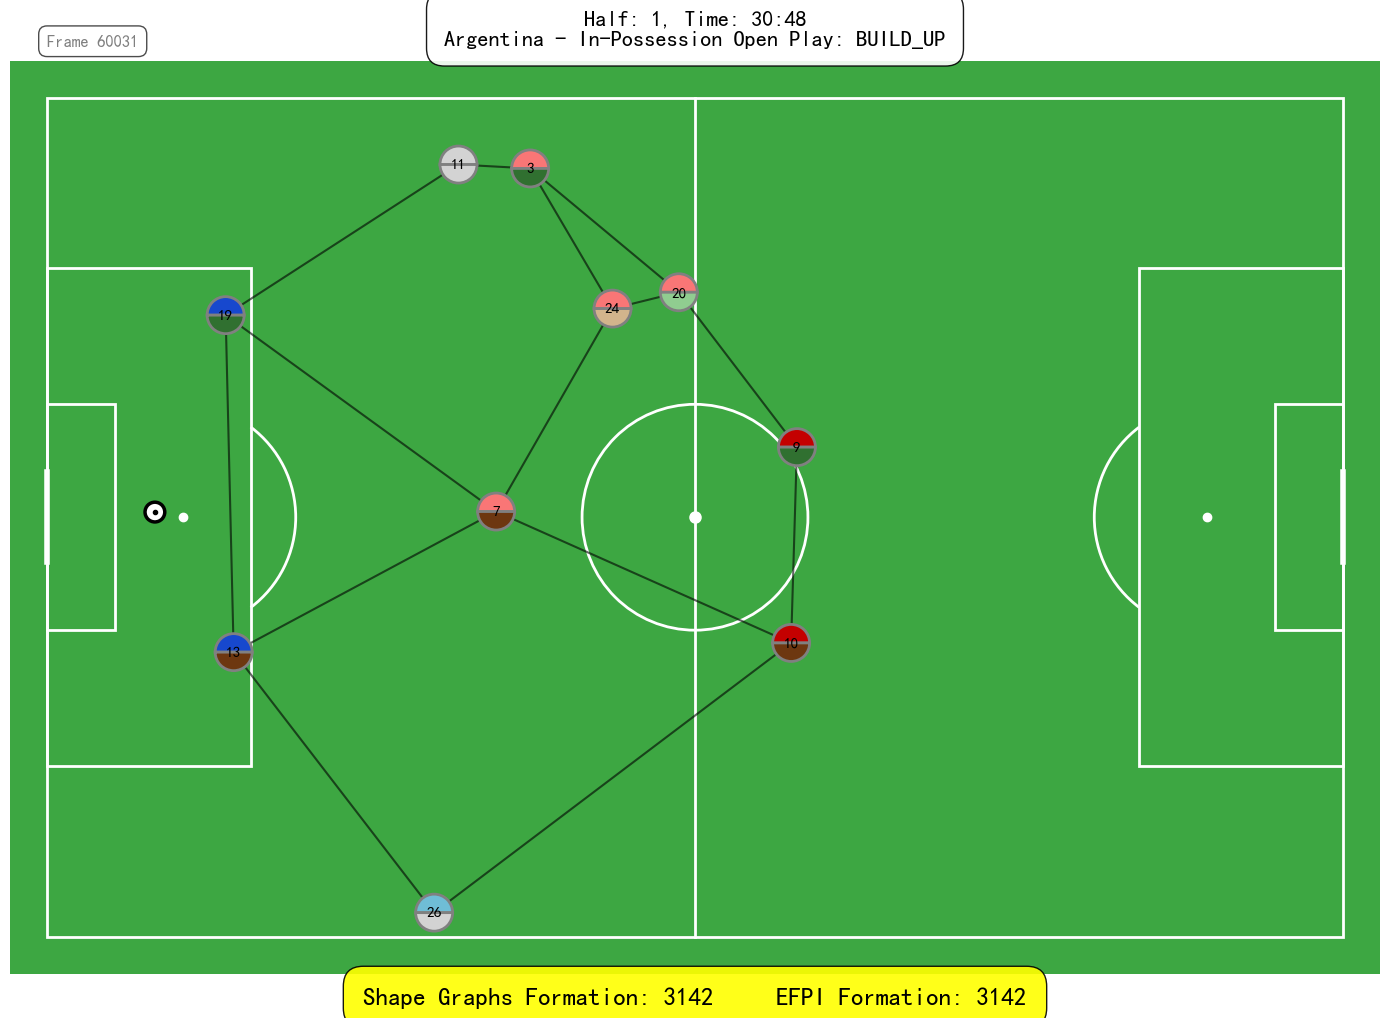


测试图片已保存: ..\..\..\data\morph_test\shapegraphs_baseline\comparison_videos\test_frame_60031.png


In [5]:
# 选择一个测试帧
test_frame_idx = len(results_df) // 2  # 中间帧
test_row = results_df.iloc[test_frame_idx]
test_frame_id = test_row['frame_id']

print(f"测试帧: {test_frame_id}")
print(f"阵型: {test_row['formation_smoothed']}")
print(f"垂直层级: {test_row['vertical_levels']}")

# 创建可视化
fig, ax = plt.subplots(figsize=(14, 10))
visualize_comparison_frame(ax, test_frame_id, test_row, show_info=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'test_frame_{test_frame_id}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n测试图片已保存: {OUTPUT_DIR / f'test_frame_{test_frame_id}.png'}")

## 6. 生成视频片段

选择一个连续的时间片段（如30秒），生成动态视频

In [6]:
# ========== 视频参数配置 ==========
FPS = 30000/1001  # 帧率（与数据采集频率一致，实现1:1播放速度）

# 时间范围配置（秒）
START_TIME = 35*60  # 开始时间（秒），例如：1800秒 = 30分钟
END_TIME = 35.5*60    # 结束时间（秒），例如：1830秒 = 30分30秒

# 🔧 修复：确保results_df按frame_id排序，保证视频帧连续
results_df_sorted = results_df.sort_values('frame_id').reset_index(drop=True)

# 🔧 新增：为results_df添加timestamp信息（用于验证时间准确性）
# 从tracking_pl中获取每个frame_id对应的timestamp
print("正在获取时间戳信息...")
frame_timestamps = {}
for frame_id in results_df_sorted['frame_id']:
    frame_data = tracking_pl.filter(pl.col('frame_id') == frame_id)
    if len(frame_data) > 0:
        timestamp = frame_data['timestamp'][0]
        if isinstance(timestamp, timedelta):
            frame_timestamps[frame_id] = timestamp.total_seconds()
        else:
            frame_timestamps[frame_id] = float(timestamp)

results_df_sorted['timestamp_seconds'] = results_df_sorted['frame_id'].map(frame_timestamps)

# 检查时间连续性
print("\n检查时间连续性...")
time_diffs = results_df_sorted['timestamp_seconds'].diff()
large_gaps = time_diffs[time_diffs > 1.0]  # 超过1秒的间隔
if len(large_gaps) > 0:
    print(f"⚠️ 发现 {len(large_gaps)} 个时间间隔 > 1秒的跳跃（可能是死球状态）")
    print(f"   最大时间间隔: {time_diffs.max():.2f} 秒")
    print(f"   平均时间间隔: {time_diffs.mean():.2f} 秒")
else:
    print("✅ 时间连续，无明显间隔")

# ========== 根据时间范围筛选帧 ==========
video_frames = results_df_sorted[
    (results_df_sorted['timestamp_seconds'] >= START_TIME) & 
    (results_df_sorted['timestamp_seconds'] <= END_TIME)
].copy()

num_frames = len(video_frames)

# ========== 显示视频参数 ==========
print(f"\n视频参数:")
print(f"  开始时间: {START_TIME}秒 ({START_TIME//60}分{START_TIME%60}秒)")
print(f"  结束时间: {END_TIME}秒 ({END_TIME//60}分{END_TIME%60}秒)")
print(f"  实际时长: {END_TIME - START_TIME}秒")
print(f"  总帧数: {num_frames}")
print(f"  帧率: {FPS} FPS")
print(f"  视频时长: {num_frames / FPS:.1f} 秒")

if num_frames == 0:
    print("\n❌ 错误：选定时间范围内没有数据帧！")
    print(f"可用时间范围: {results_df_sorted['timestamp_seconds'].min():.1f}s - {results_df_sorted['timestamp_seconds'].max():.1f}s")
else:
    print(f"  ✅ 帧ID范围: {video_frames['frame_id'].min()} - {video_frames['frame_id'].max()}")
    print(f"  ✅ 时间范围: {video_frames['timestamp_seconds'].iloc[0]:.2f}s - {video_frames['timestamp_seconds'].iloc[-1]:.2f}s")

正在获取时间戳信息...

检查时间连续性...
⚠️ 发现 51 个时间间隔 > 1秒的跳跃（可能是死球状态）
   最大时间间隔: 142.78 秒
   平均时间间隔: 0.06 秒

视频参数:
  开始时间: 2100秒 (35分0秒)
  结束时间: 2130.0秒 (35.0分30.0秒)
  实际时长: 30.0秒
  总帧数: 663
  帧率: 29.97002997002997 FPS
  视频时长: 22.1 秒
  ✅ 帧ID范围: 67581 - 68243
  ✅ 时间范围: 2100.47s - 2122.56s


In [7]:
# 创建视频
print("\n开始生成视频...")

fig, ax = plt.subplots(figsize=(14, 10))

def update_frame(frame_idx):
    """更新函数（用于动画）"""
    row = video_frames.iloc[frame_idx]
    frame_id = row['frame_id']
    visualize_comparison_frame(ax, frame_id, row, show_info=True)
    return ax,

# 创建动画
anim = FuncAnimation(
    fig, update_frame, 
    frames=len(video_frames),
    interval=1000/FPS,  # 毫秒
    blit=False
)

# 保存视频
video_file = OUTPUT_DIR / f'shape_graphs_video_{GAME_ID}_segment.mp4'
# 使用分数表示29.97 FPS（NTSC标准：30000/1001）
writer = FFMpegWriter(fps='30000/1001', bitrate=2000)

print(f"保存视频到: {video_file}")
print(f"这可能需要几分钟...")

anim.save(str(video_file), writer=writer, dpi=100)
plt.close()

print(f"\n✅ 视频生成完成！")
print(f"文件: {video_file}")
print(f"时长: {num_frames / FPS:.1f} 秒")
print(f"分辨率: 1400x1000")
print(f"帧率: {FPS} FPS")


开始生成视频...
保存视频到: ..\..\..\data\morph_test\shapegraphs_baseline\comparison_videos\shape_graphs_video_10517_segment.mp4
这可能需要几分钟...

✅ 视频生成完成！
文件: ..\..\..\data\morph_test\shapegraphs_baseline\comparison_videos\shape_graphs_video_10517_segment.mp4
时长: 22.1 秒
分辨率: 1400x1000
帧率: 29.97002997002997 FPS


## 7. 生成关键帧对比图

选择几个代表性帧，展示不同阵型的Shape Graphs

发现的阵型: ['2-5-3' '3-5-2' '3-6-1' '4-5-1' '3-4-3' '1-6-3' '2-4-4' '4-4-2' '4-3-3'
 '5-4-1' '2-7-1' '2-6-2' '5-3-2' '2-3-5' '2-2-6' '3-3-4' '6-3-1' '1-5-4'
 '1-7-2' '1-4-5' '1-8-1']

选择了 4 个关键帧


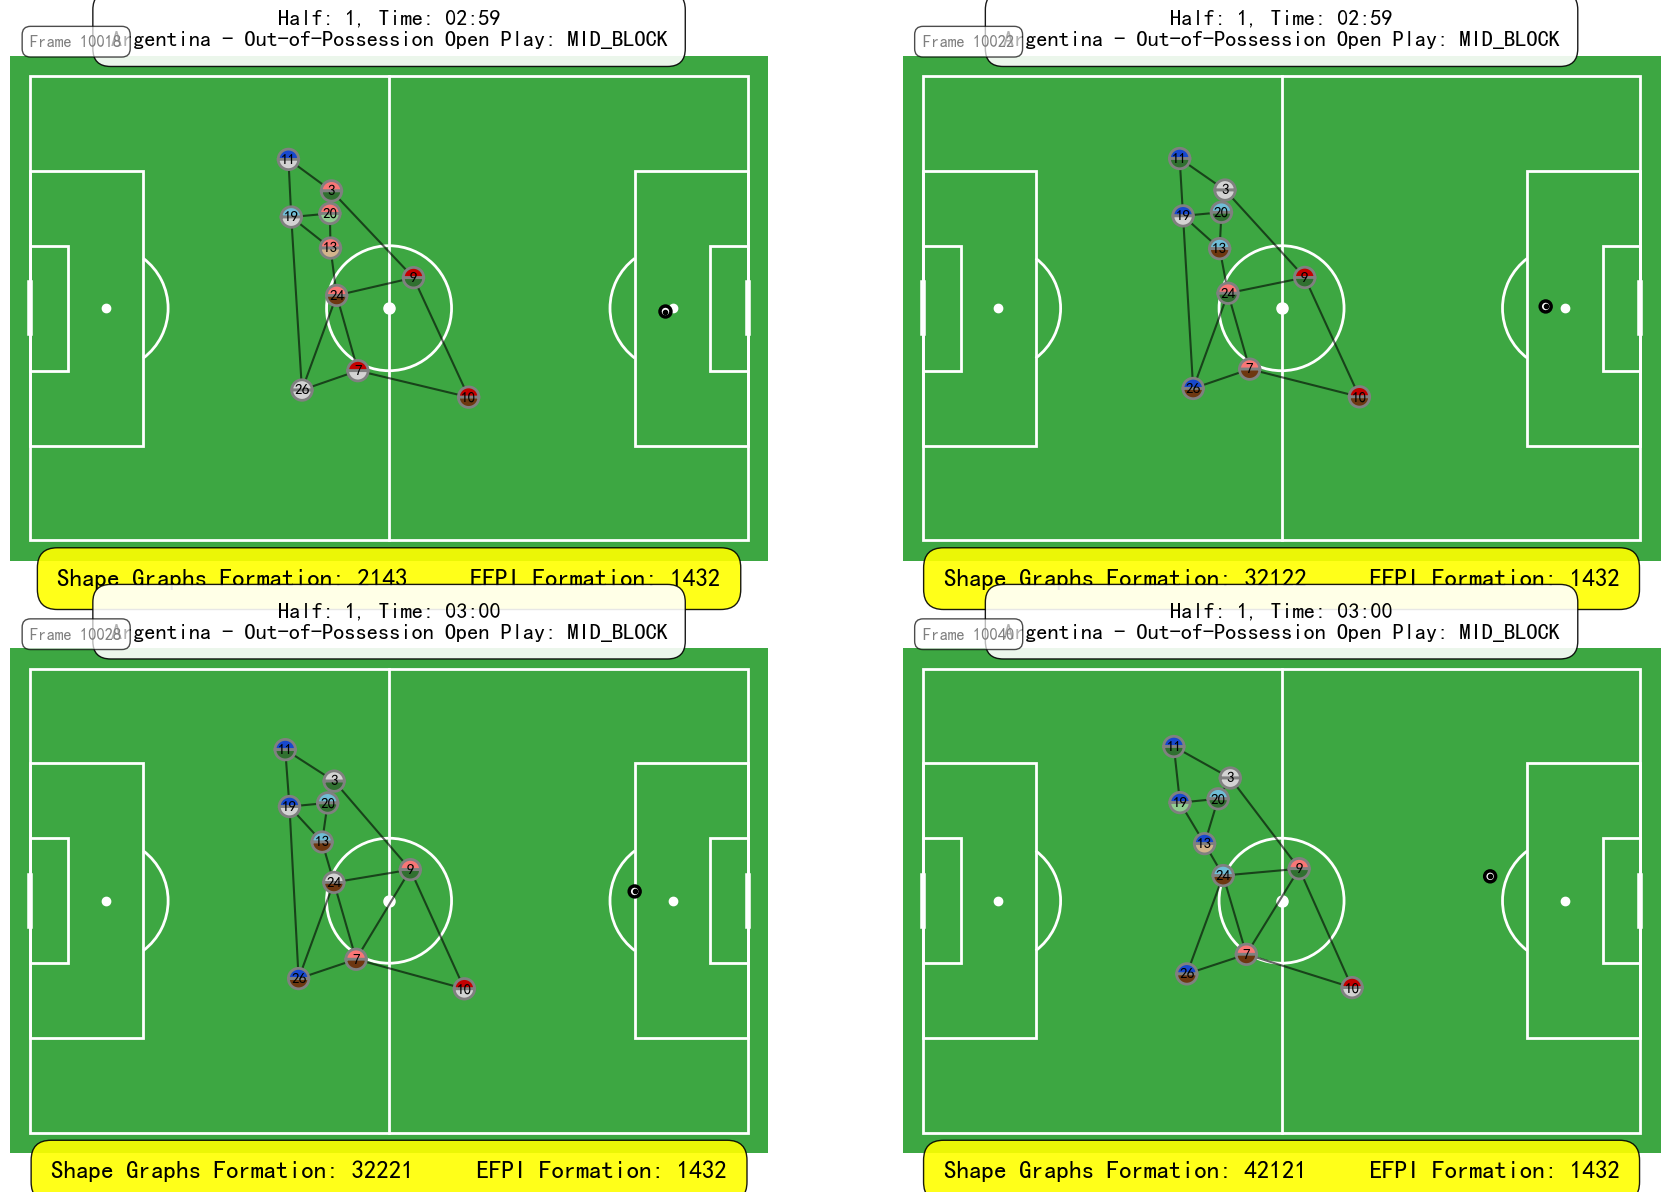


关键帧对比图已保存: ..\..\..\data\morph_test\shapegraphs_baseline\comparison_videos\key_frames_comparison_10517.png


In [8]:
# 选择不同阵型的代表性帧
formations = results_df['formation_smoothed'].unique()
print(f"发现的阵型: {formations}")

# 为每个阵型选择一个代表帧
key_frames = []
for formation in formations[:4]:  # 最多6个
    frame_row = results_df[results_df['formation_smoothed'] == formation].iloc[0]
    key_frames.append(frame_row)

print(f"\n选择了 {len(key_frames)} 个关键帧")

# 创建对比图
n_frames = len(key_frames)
n_cols = 2
n_rows = (n_frames + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_frames > 1 else [axes]

for idx, row in enumerate(key_frames):
    frame_id = row['frame_id']
    visualize_comparison_frame(axes[idx], frame_id, row, show_info=True)
    

# 隐藏多余的子图
for idx in range(len(key_frames), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
comparison_file = OUTPUT_DIR / f'key_frames_comparison_{GAME_ID}.png'
plt.savefig(comparison_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n关键帧对比图已保存: {comparison_file}")

## 8. 添加图例说明

C:\Users\11254\AppData\Local\Temp\ipykernel_38268\1793845808.py:67: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  plt.savefig(legend_file, dpi=150, bbox_inches='tight')
e:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH\MORPHenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8226 (\N{BULLET}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


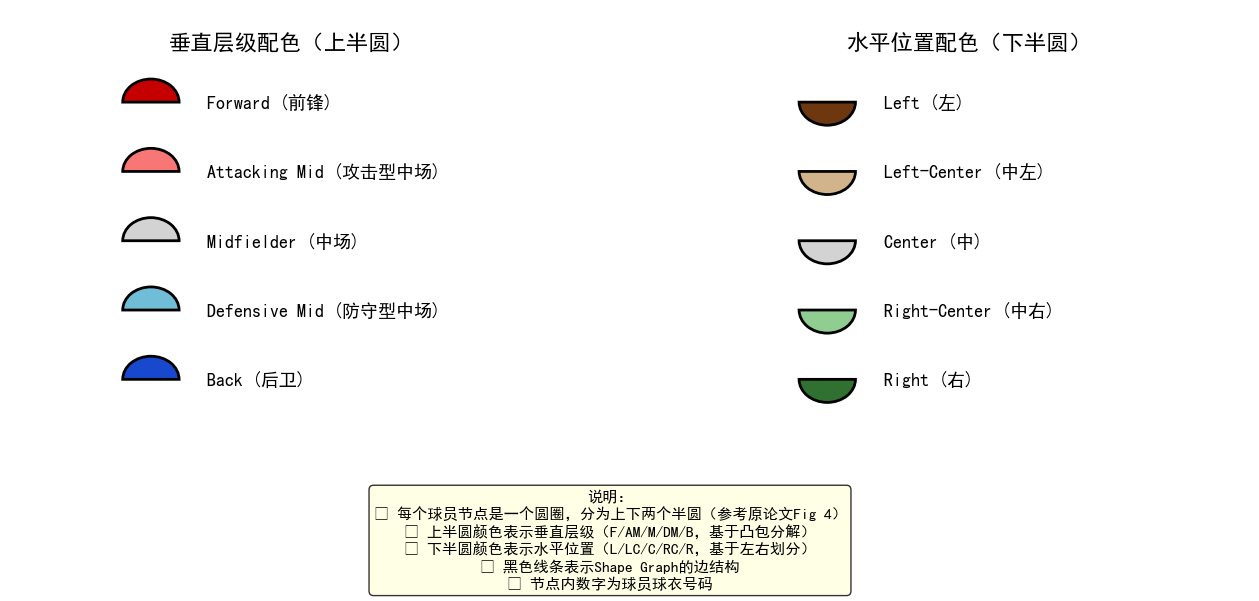

图例已保存: ..\..\..\data\morph_test\shapegraphs_baseline\comparison_videos\color_legend.png


In [9]:
# 创建图例（双色半圆设计）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# === 左侧：垂直层级（上半圆） ===
ax1.axis('off')
ax1.text(0.5, 0.95, '垂直层级配色（上半圆）', 
         ha='center', va='top', fontsize=16, fontweight='bold',
         transform=ax1.transAxes)

y_start = 0.8
y_step = 0.15

for idx, (level, color) in enumerate(VERTICAL_COLORS.items()):
    y_pos = y_start - idx * y_step
    
    # 绘制上半圆示例
    wedge = patches.Wedge(
        center=(0.25, y_pos), r=0.05,
        theta1=0, theta2=180,
        facecolor=color, edgecolor='black', linewidth=2,
        transform=ax1.transAxes
    )
    ax1.add_patch(wedge)
    
    # 标注文字
    ax1.text(0.35, y_pos, VERTICAL_NAMES[level],
             ha='left', va='center', fontsize=13,
             transform=ax1.transAxes)

# === 右侧：水平位置（下半圆） ===
ax2.axis('off')
ax2.text(0.5, 0.95, '水平位置配色（下半圆）', 
         ha='center', va='top', fontsize=16, fontweight='bold',
         transform=ax2.transAxes)

for idx, (pos, color) in enumerate(HORIZONTAL_COLORS.items()):
    y_pos = y_start - idx * y_step
    
    # 绘制下半圆示例
    wedge = patches.Wedge(
        center=(0.25, y_pos), r=0.05,
        theta1=180, theta2=360,
        facecolor=color, edgecolor='black', linewidth=2,
        transform=ax2.transAxes
    )
    ax2.add_patch(wedge)
    
    # 标注文字
    ax2.text(0.35, y_pos, HORIZONTAL_NAMES[pos],
             ha='left', va='center', fontsize=13,
             transform=ax2.transAxes)

# 说明文字（跨越两个子图）
note_text = (
    "说明：\n"
    "• 每个球员节点是一个圆圈，分为上下两个半圆（参考原论文Fig 4）\n"
    "• 上半圆颜色表示垂直层级（F/AM/M/DM/B，基于凸包分解）\n"
    "• 下半圆颜色表示水平位置（L/LC/C/RC/R，基于左右划分）\n"
    "• 黑色线条表示Shape Graph的边结构\n"
    "• 节点内数字为球员球衣号码"
)
fig.text(0.5, 0.08, note_text,
         ha='center', va='top', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

legend_file = OUTPUT_DIR / 'color_legend.png'
plt.savefig(legend_file, dpi=150, bbox_inches='tight')
plt.show()

print(f"图例已保存: {legend_file}")

## 9. 总结

本notebook完成了以下工作：

1. ✅ **色块标注**: 根据垂直层级（F/AM/M/DM/B）给球员节点着色
2. ✅ **Shape Graph可视化**: 显示图的边结构
3. ✅ **信息显示**: 显示阵型、比赛时间、半场、球队信息
4. ✅ **动态视频**: 生成连续时间戳的MP4视频文件
5. ✅ **关键帧对比**: 展示不同阵型的代表性帧
6. ✅ **图例说明**: 提供清晰的配色方案说明

## 输出文件

- `test_frame_*.png`: 测试帧可视化
- `shape_graphs_video_10517_segment.mp4`: 30秒视频片段
- `key_frames_comparison_10517.png`: 关键帧对比图
- `color_legend.png`: 配色方案图例

## 使用说明

1. **调整视频参数**: 修改`VIDEO_DURATION`和`FPS`来控制视频时长和帧率
2. **选择时间段**: 修改`START_FRAME_IDX`来选择不同的时间段
3. **自定义配色**: 修改`LEVEL_COLORS`字典来使用不同的颜色方案
4. **FFmpeg要求**: 生成视频需要安装FFmpeg

## 下一步

- 可以为整场比赛生成完整视频
- 可以添加球的位置显示
- 可以添加守门员位置显示
- 可以添加阵型变化的高亮标记